# Quick Sort

**Quick Sort** is a divide-and-conquer sorting algorithm that selects a **pivot element** and partitions the array so that smaller elements are placed on one side and larger elements on the other.

## How It Works

1. **Choose Pivot:** Select an element from the array as the pivot.
2. **Partition:** Rearrange the array so that elements smaller than the pivot are placed before it and larger elements are placed after it.
3. **Repeat:** Recursively apply the same process to the left and right portions of the array.
4. **Combine:** Once the partitions are sorted, the entire array is sorted.

## Summary

* **Approach:** Divide and Conquer.
* **Average Time Complexity:** O(n log n).
* **Worst Time Complexity:** O(n²).
* **Space Complexity:** O(log n) on average for recursive calls.
* **Key Point:** Performance depends heavily on how effectively the pivot divides the array.


In [ ]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np


#pivot at first
def quick_sort(values):
    comparisons = 0

    if len(values) <= 1:
        return values, comparisons

    pivot = values[0]

    left = []
    right = []

    for value in values[1:]:
        comparisons += 1

        if value <= pivot:
            left.append(value)
        else:
            right.append(value)

    sorted_left, left_comparisons = quick_sort(left)
    sorted_right, right_comparisons = quick_sort(right)

    comparisons += left_comparisons + right_comparisons

    return sorted_left + [pivot] + sorted_right, comparisons

# Best, Average and Worst Case for Quick Sort

* **Best Case Scenario:** When the pivot divides the array into two **approximately equal halves**.
* **Average Case Scenario:** When the pivot generally produces reasonably balanced partitions.
* **Worst Case Scenario:** When the pivot is repeatedly the **smallest or largest element**, creating highly unbalanced partitions.
* **Time Complexity:** O(n log n) for Best and Average Case, O(n²) for Worst Case.

- **Best Case:** Balanced partitions reduce the problem size by roughly half at each recursive step, resulting in **O(n log n)** time.
- **Average Case:** With reasonably balanced partitions, Quick Sort performs approximately **O(n log n)** comparisons.
- **Worst Case:** If each pivot produces a partition of size n - 1 and 0, the algorithm performs **O(n²)** work.
- **Pivot Selection:** Choosing a good pivot is important because it can significantly affect the performance of Quick Sort.



In [ ]:
def create_array(n):
    return random.sample(range(1, n * 10 + 1), n)

def create_quick_best_array(values):
    if len(values) <= 1:
        return values

    values = sorted(values)

    middle = len(values) // 2

    pivot = values[middle]

    left_values = values[:middle]
    right_values = values[middle + 1:]

    left_part = create_quick_best_array(left_values)
    right_part = create_quick_best_array(right_values)

    return [pivot] + left_part + right_part

In [ ]:
import random

sizes = [2, 4, 8, 16, 32, 64, 128]

trials = 100

random.seed(42)


quick_best = []
quick_average = []
quick_worst = []


for n in sizes:


    arr = create_quick_best_array(list(range(n)))
    _, comparisons = quick_sort(arr)
    quick_best.append(comparisons)

    total = 0

    for _ in range(trials):
        arr = create_array(n)
        _, comparisons = quick_sort(arr)
        total += comparisons

    quick_average.append(total / trials)

    arr = list(range(n))
    _, comparisons = quick_sort(arr)
    quick_worst.append(comparisons)

print("\nQUICK SORT")
print("=" * 55)
print(f"{'Size':<10}{'Best':<15}{'Average':<15}{'Worst':<15}")
print("-" * 55)

for i in range(len(sizes)):
    print(
        f"{sizes[i]:<10}"
        f"{quick_best[i]:<15.2f}"
        f"{quick_average[i]:<15.2f}"
        f"{quick_worst[i]:<15.2f}"
    )



QUICK SORT
Size      Best           Average        Worst          
-------------------------------------------------------
2         1.00           1.00           1.00           
4         4.00           4.91           6.00           
8         13.00          17.10          28.00          
16        38.00          51.59          120.00         
32        103.00         141.62         496.00         
64        264.00         356.39         2016.00        
128       649.00         887.81         8128.00        


# Plotting Graphs

With our code for Quick Sort done and the data for best, average and worst case for various array sizes collected, we can now plot them into graphs for observation.


# QUICK SORT - BEST CASE

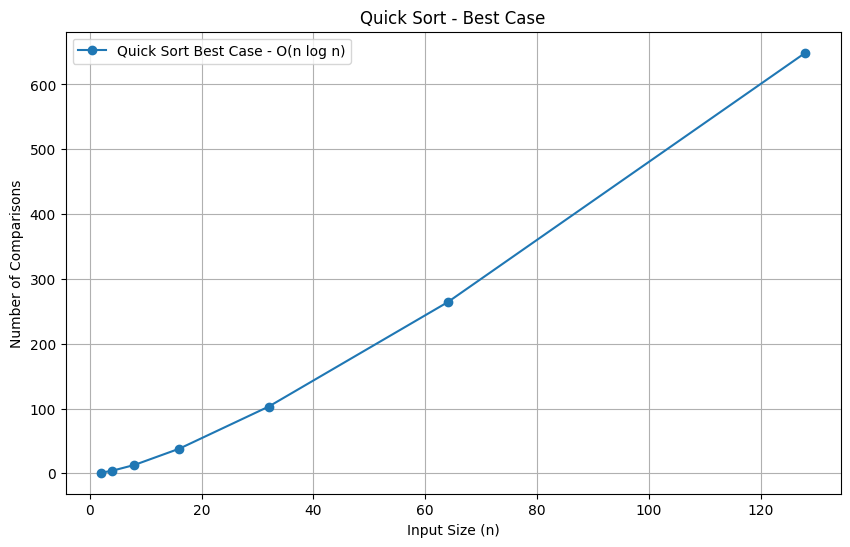

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    quick_best,
    marker='o',
    label='Quick Sort Best Case - O(n log n)'
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Quick Sort - Best Case")

plt.legend()
plt.grid(True)

plt.show()





# QUICK SORT - AVERAGE CASE

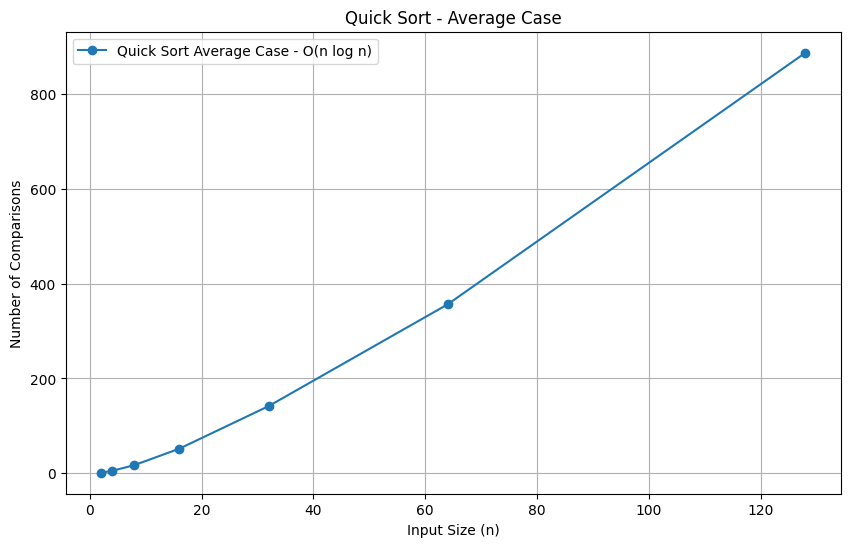

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    quick_average,
    marker='o',
    label='Quick Sort Average Case - O(n log n)'
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Quick Sort - Average Case")

plt.legend()
plt.grid(True)

plt.show()





# QUICK SORT - WORST CASE

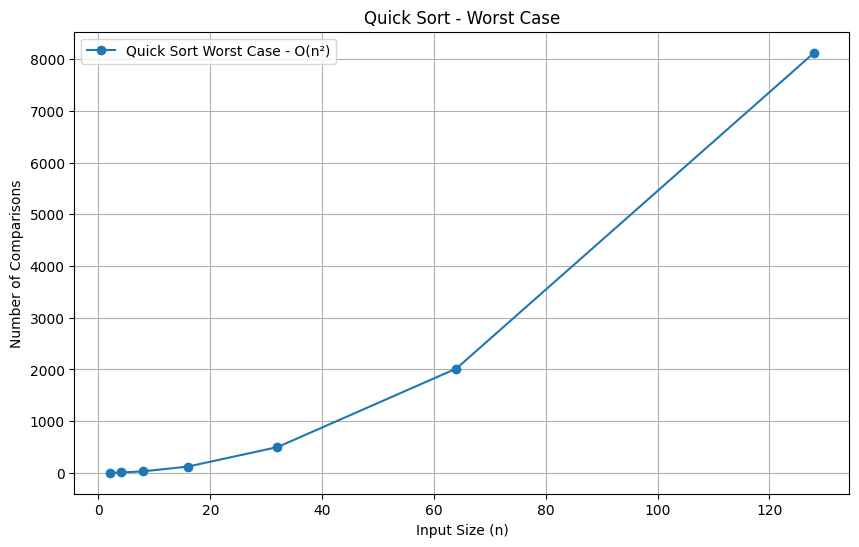

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    quick_worst,
    marker='o',
    label='Quick Sort Worst Case - O(n²)'
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Quick Sort - Worst Case")

plt.legend()
plt.grid(True)

plt.show()

# QUICK SORT - BEST< AVERAGE AND WORST CASES

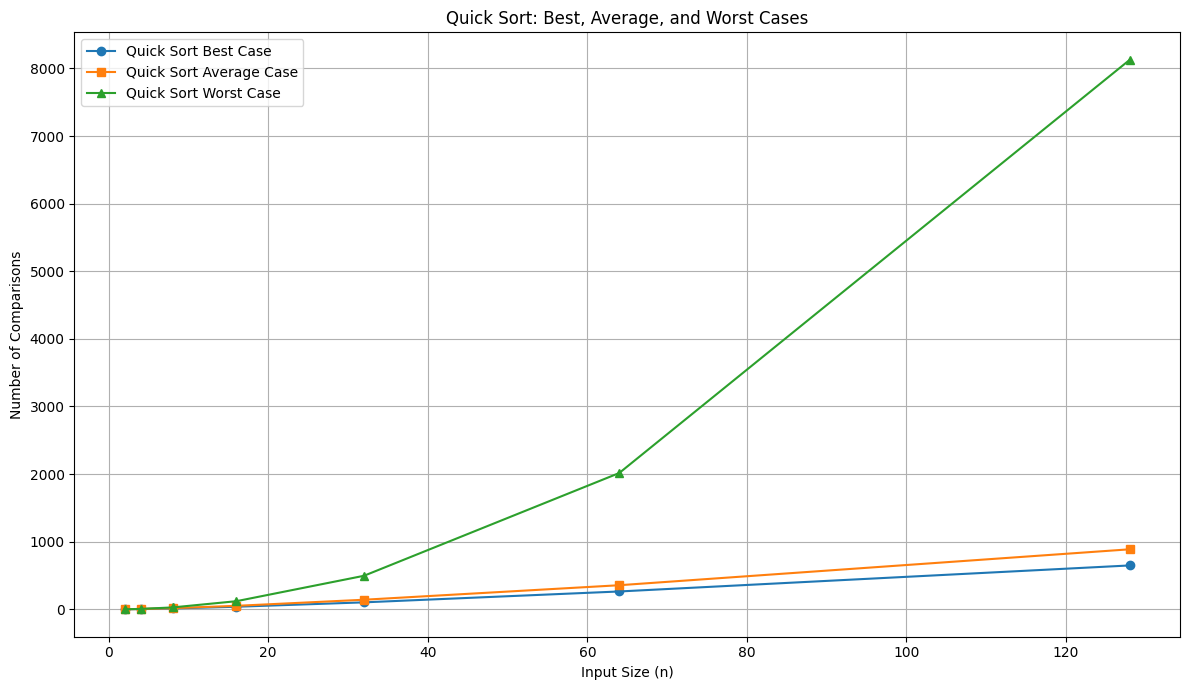

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(
    sizes,
    quick_best,
    marker="o",
    label="Quick Sort Best Case"
)

plt.plot(
    sizes,
    quick_average,
    marker="s",
    label="Quick Sort Average Case"
)

plt.plot(
    sizes,
    quick_worst,
    marker="^",
    label="Quick Sort Worst Case"
)

plt.title("Quick Sort: Best, Average, and Worst Cases")
plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Quick Sort Implementation Using Lomuto Partition :

**Quick Sort** is implemented using the **Lomuto partition scheme**, where the last element of the current subarray is selected as the pivot. The code also counts the number of comparisons made during sorting.

## How It Works

1. **Choose Pivot:** The last element of the current subarray is selected as the pivot.
2. **Partition:** Each element is compared with the pivot. Elements smaller than or equal to the pivot are moved to the left.
3. **Place Pivot:** The pivot is swapped into its correct position after partitioning.
4. **Recurse:** Quick Sort is recursively applied to the subarrays on the left and right of the pivot.
5. **Count Comparisons:** Each comparison with the pivot is recorded in `stats["comparisons"]`.

## Best Case

The `best_case_lomuto()` function creates an input where the pivot produces **balanced partitions**.

- The pivot is positioned so that the left and right partitions are approximately equal.
- The problem size is reduced by roughly half at each recursive level.
- **Time Complexity:** O(n log n)

## Average Case

The average case is tested using **random permutations** of the input array.

- 30 random arrays are generated for each input size.
- The number of comparisons is recorded for each trial.
- The average number of comparisons is calculated.
- **Time Complexity:** O(n log n)

## Worst Case

The worst case occurs when the pivot is repeatedly the **smallest or largest element**.

- Using the last element as the pivot, already sorted ascending or descending arrays produce highly unbalanced partitions.
- One partition contains `n - 1` elements while the other contains `0`.
- The number of comparisons follows:

$$
1 + 2 + 3 + \cdots + (n-1) = \frac{n(n-1)}{2}
$$

- **Time Complexity:** O(n²)

## Randomized Quick Sort

The `randomized_partition()` function randomly selects the pivot instead of always using the last element.

- This reduces the likelihood of repeatedly choosing a poor pivot.
- Multiple trials are performed using different random seeds.
- Randomized Quick Sort has an **expected time complexity of O(n log n)**.
- Its worst-case complexity is still **O(n²)**, but the probability of encountering it is much lower.

## Summary

| Case | Pivot Behaviour | Time Complexity |
|---|---|---|
| **Best** | Balanced partitions | O(n log n) |
| **Average** | Reasonably balanced partitions | O(n log n) |
| **Worst** | Highly unbalanced partitions | O(n²) |

**Key Point:** The performance of Quick Sort depends heavily on **pivot selection**. Balanced pivots produce efficient sorting, while consistently poor pivots can lead to quadratic performance.


In [ ]:


def partition_last(a, low, high, stats):
  pivot = a[high]
  i = low - 1

  for j in range(low, high):
    stats["comparisons"] += 1
    if a[j] <= pivot:
      i += 1
      a[i], a[j] = a[j], a[i]

  a[i + 1], a[high] = a[high], a[i + 1]
  return i + 1


def quicksort_last(a, low, high, stats):
  if low < high:
    q = partition_last(a, low, high, stats)
    quicksort_last(a, low, q - 1, stats)
    quicksort_last(a, q + 1, high, stats)


def counted_quicksort(a):
  b = a.copy()
  stats = {"comparisons": 0}
  quicksort_last(b, 0, len(b) - 1, stats)
  return b, stats["comparisons"]


def best_case_lomuto(values):
  values = sorted(values)
  n = len(values)
  if n < 1:
    return values
  m = (n - 1) // 2
  pivot = values[m]
  left = best_case_lomuto(values[:m])
  right = best_case_lomuto(values[m + 1:])
  if right:
    right_before_partition = [right[-1]] + right[:-1]
  else:
    right_before_partition = []
  return left + right_before_partition + [pivot]


def alpha_case_lomuto(values, alpha):
  values = sorted(values)
  n = len(values)
  if n <= 1:
    return values
  m = round(alpha * (n - 1))
  m = max(0, min(n - 1, m))
  pivot = values[m]
  left = alpha_case_lomuto(values[:m], alpha)
  right = alpha_case_lomuto(values[m + 1:], alpha)
  if right:
    right_before_partition = [right[-1]] + right[:-1]
  else:
    right_before_partition = []
  return left + right_before_partition + [pivot]


def randomized_partition(a, low, high, stats):
  pivot_index = random.randint(low, high)
  a[pivot_index], a[high] = a[high], a[pivot_index]
  return partition_last(a, low, high, stats)


def randomized_quicksort(a, low, high, stats):
  if low < high:
    q = randomized_partition(a, low, high, stats)
    randomized_quicksort(a, low, q - 1, stats)
    randomized_quicksort(a, q + 1, high, stats)


def counted_randomized_quicksort(a, seed=None):
  if seed is not None:
    random.seed(seed)
  b = a.copy()
  stats = {"comparisons": 0}
  randomized_quicksort(b, 0, len(b) - 1, stats)
  return b, stats["comparisons"]


def compare_on_input(base, trials=30):
  _, det = counted_quicksort(base)
  rand_counts = []
  for seed in range(trials):
    _, c = counted_randomized_quicksort(base, seed=seed)
    rand_counts.append(c)
  rand_mean = sum(rand_counts) / trials
  return det, rand_mean


def run_experiments():
  print("--- Task 2: Worst Case Experiment ---")
  for n in [16, 32, 64, 128, 256, 512]:
    ascending = list(range(1, n + 1))
    descending = list(range(n, 0, -1))
    _, c1 = counted_quicksort(ascending)
    _, c2 = counted_quicksort(descending)
    expected_worst = n * (n - 1) // 2
    print(
        f"n={n:4d} | Ascending: {c1:6d} | Descending: {c2:6d} | Formula:"
        f" {expected_worst:6d}"
    )

  print("\n--- Task 3: Best Case Experiment ---")
  for n in [8, 16, 32, 64, 128, 256, 512]:
    a = best_case_lomuto(range(1, n + 1))
    _, comparisons = counted_quicksort(a)
    reference = n * math.log2(n)
    ratio = comparisons / reference if reference > 0 else 0
    print(
        f"n={n:4d} | C(n)={comparisons:6d} | n*log2(n)={reference:8.1f} | Ratio:"
        f" {ratio:.4f}"
    )

  print("\n--- Task 4: Average Case (Random Permutations) ---")
  for n in [16, 32, 64, 128, 256, 512]:
    trial_counts = []
    for _ in range(30):
      a = list(range(1, n + 1))
      random.shuffle(a)
      _, c = counted_quicksort(a)
      trial_counts.append(c)
    mean_c = sum(trial_counts) / len(trial_counts)
    print(
        f"n={n:4d} | Mean Comparisons: {mean_c:8.2f} | Ratio:"
        f" {mean_c / (n * math.log2(n)):.4f}"
    )


if __name__ == "__main__":
  run_experiments()

--- Task 2: Worst Case Experiment ---
n=  16 | Ascending:    120 | Descending:    120 | Formula:    120
n=  32 | Ascending:    496 | Descending:    496 | Formula:    496
n=  64 | Ascending:   2016 | Descending:   2016 | Formula:   2016
n= 128 | Ascending:   8128 | Descending:   8128 | Formula:   8128
n= 256 | Ascending:  32640 | Descending:  32640 | Formula:  32640
n= 512 | Ascending: 130816 | Descending: 130816 | Formula: 130816

--- Task 3: Best Case Experiment ---
n=   8 | C(n)=    13 | n*log2(n)=    24.0 | Ratio: 0.5417
n=  16 | C(n)=    38 | n*log2(n)=    64.0 | Ratio: 0.5938
n=  32 | C(n)=   103 | n*log2(n)=   160.0 | Ratio: 0.6438
n=  64 | C(n)=   264 | n*log2(n)=   384.0 | Ratio: 0.6875
n= 128 | C(n)=   649 | n*log2(n)=   896.0 | Ratio: 0.7243
n= 256 | C(n)=  1546 | n*log2(n)=  2048.0 | Ratio: 0.7549
n= 512 | C(n)=  3595 | n*log2(n)=  4608.0 | Ratio: 0.7802

--- Task 4: Average Case (Random Permutations) ---
n=  16 | Mean Comparisons:    51.27 | Ratio: 0.8010
n=  32 | Mean Comp

# Partition Imbalance Analysis in Divide-and-Conquer Sorting

* **Overview:** This script analyzes how partition imbalance (represented by the parameter $\alpha$) affects the leading constant factor in the $O(n \log_2 n)$ time complexity of divide-and-conquer algorithms like Quicksort.
* **Entropy-Based Scaling:** For each split ratio $\alpha$, the binary entropy $H(\alpha)$ is computed as $- \alpha \log_2(\alpha) - (1 - \alpha) \log_2(1 - \alpha)$, which determines the scaling factor $K = \frac{1}{H(\alpha)}$.
* **Growth Curves:** The script calculates $y = K \cdot n \log_2(n)$ across various input sizes ($n$) from 16 to 1024, plotting distinct curves for each alpha value.
* **Visual Insight:** As $\alpha$ moves closer to $0.5$ (balanced splits), entropy is maximized and the constant $K$ is minimized ($1.0$), resulting in the lowest curve. As partitions become more imbalanced (approaching $0.1$ or $0.99$), entropy decreases, causing $K$ to increase significantly and the curve to rise sharply.
* **Conclusion:** Balanced partitions yield the most efficient execution constants, while severe imbalance degrades performance by increasing the scaling factor of the $n \log n$ growth rate.

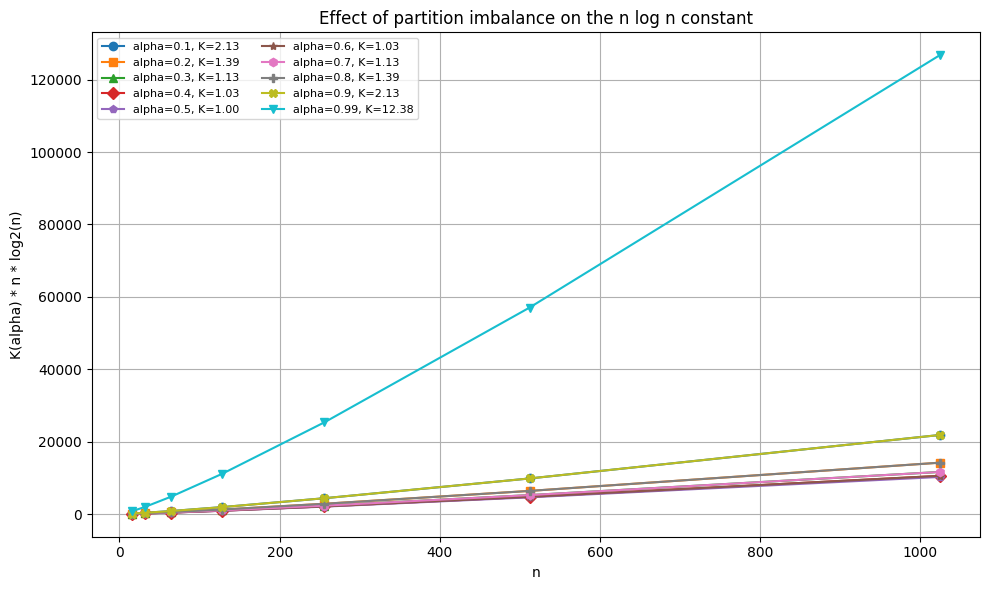

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
ns = np.array([16, 32, 64, 128, 256, 512, 1024])

plt.figure(figsize=(10, 6))

markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'P', 'X', 'v']

for i, alpha in enumerate(alphas):
  h2 = -alpha * math.log2(alpha) - (1 - alpha) * math.log2(1 - alpha)
  k = 1.0 / h2
  y = k * ns * np.log2(ns)
  plt.plot(ns, y, marker=markers[i % len(markers)], label=f"alpha={alpha}, K={k:.2f}")

plt.xlabel("n")
plt.ylabel("K(alpha) * n * log2(n)")
plt.title("Effect of partition imbalance on the n log n constant")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Deterministic vs. Randomized Quicksort on Sorted Inputs

* **Overview:** This script benchmarks and compares the performance of standard (deterministic) Quicksort against Randomized Quicksort when given an already sorted input array across varying input sizes ($n$ from 32 to 512).
* **Experimental Setup:** For each input size, it generates a sorted list from $1$ to $n$ and averages the number of comparisons over 30 trials using a custom `compare_on_input` function.
* **Algorithm Behavior:**
  * **Deterministic Quicksort:** Typically picks a fixed pivot (like the first or last element). On a sorted input, this results in completely unbalanced partitions, degrading its performance to a worst-case $O(n^2)$ complexity.
  * **Randomized Quicksort:** Selects a random pivot, which helps avoid worst-case behaviors on pre-sorted data, maintaining an expected $O(n \log n)$ performance.
* **Visual Insight:** The resulting plot contrasts the sharp, quadratic growth of normal Quicksort against the much flatter, efficient scaling of Randomized Quicksort on the exact same sorted dataset.
* **Conclusion:** Randomized pivoting effectively neutralizes the worst-case vulnerability of Quicksort when dealing with pre-sorted or nearly sorted inputs.

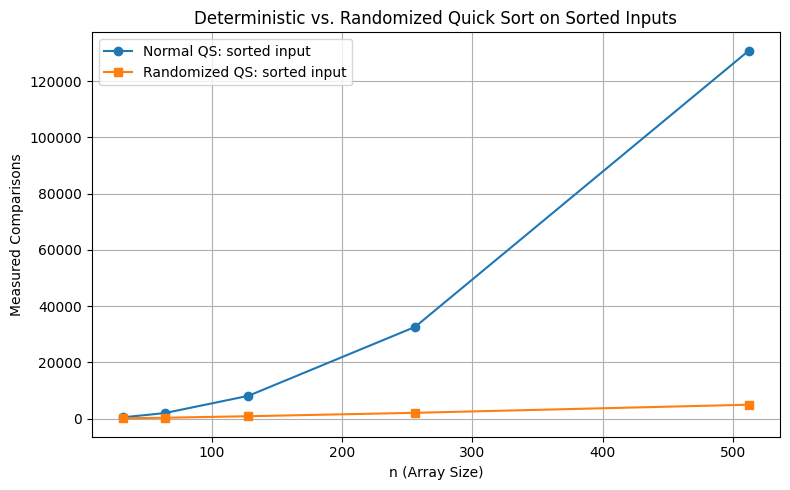

In [ ]:
import matplotlib.pyplot as plt

ns = [32, 64, 128, 256, 512]
det_sorted = []
rnd_sorted = []

for n in ns:
  a = list(range(1, n + 1))
  det, rnd = compare_on_input(a, trials=30)
  det_sorted.append(det)
  rnd_sorted.append(rnd)

plt.figure(figsize=(8, 5))
plt.plot(ns, det_sorted, marker="o", label="Normal QS: sorted input")
plt.plot(ns, rnd_sorted, marker="s", label="Randomized QS: sorted input")

plt.xlabel("n (Array Size)")
plt.ylabel("Measured Comparisons")
plt.title("Deterministic vs. Randomized Quick Sort on Sorted Inputs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

* **Core Efficiency:** Quicksort is one of the fastest and most efficient comparison-based sorting algorithms in practice, boasting an average-case time complexity of $O(n \log n)$ due to its divide-and-conquer strategy.
* **In-Place Sorting:** Unlike merge sort, standard quicksort operates largely in-place with a low memory overhead, typically requiring an auxiliary space complexity of $O(\log n)$ for the recursion stack.
* **Worst-Case Vulnerability:** Standard deterministic implementations suffer from a worst-case time complexity of $O(n^2)$ when encountering pathological inputs, such as already sorted or reverse-sorted data with poor pivot choices.
* **Mitigation Through Randomization:** Employing randomized pivot selection effectively neutralizes worst-case pitfalls, ensuring expected $O(n \log n)$ performance across nearly all input distributions.
* **Final Verdict:** Quicksort remains a standard choice for general-purpose sorting in various system libraries, provided careful pivot selection strategies are utilized to maintain balanced partitions.